In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import quantstats as qs
import empyrical as ep
import os
import matplotlib.pyplot as plt; plt.rcdefaults()

In [2]:
# !pip install fanchart
%cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [3]:
# !pip install -e /Users/safishajjouz/GitHub/QuantitativePortfolioManagement
# set env to: jupyter_env 
from maData.getdata import get_US_yields, get_fx
from myPortfolioManagement.myData import get_stock_prices
from myPortfolioManagement.myTimeSeries import make_sma
from myPortfolioManagement.myBacktesting import performance, prep_dist, plot_fan_chart
from myPortfolioManagement.myPerformanceMetrics import performance_overview, get_main_stats
from myPortfolioManagement.myPlots import monthly_heatmap
from myPortfolioManagement.myBootstrapping import bootstrappingTS
from myPortfolioManagement.myReturns import returns_from_prices

# Get data 

In [27]:
# download US Yields
# ======================================================================================================================
df_USyields = get_US_yields(freq='d', add_fed_rate=True)

# define slope
# ======================================================================================================================
df = df_USyields[['2Y', 'DFF', '1Y']].copy()
df['Slope2Y'] = df['DFF'] - df['2Y']  # if 2Y > DFF, means markets expect Fed to increase rates


# Get data trading instruments: EURUSD, Stocks, Japan
# ======================================================================================================================

# get Benchmark 
yah00_ticker = '^GSPC'
bench = 'S&P500'
df_stock = get_stock_prices(yahoo_tickers=[yah00_ticker], wide_format=True)
df_stock = df_stock.rename(columns={yah00_ticker: bench})

# get FX 
df_fx = get_fx(cross = "JPYUSD")

df_assets = pd.concat([df_stock, df_fx], axis=1)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 8830.11it/s]

get_stock_prices took 809.98ms


<Axes: xlabel='Date'>

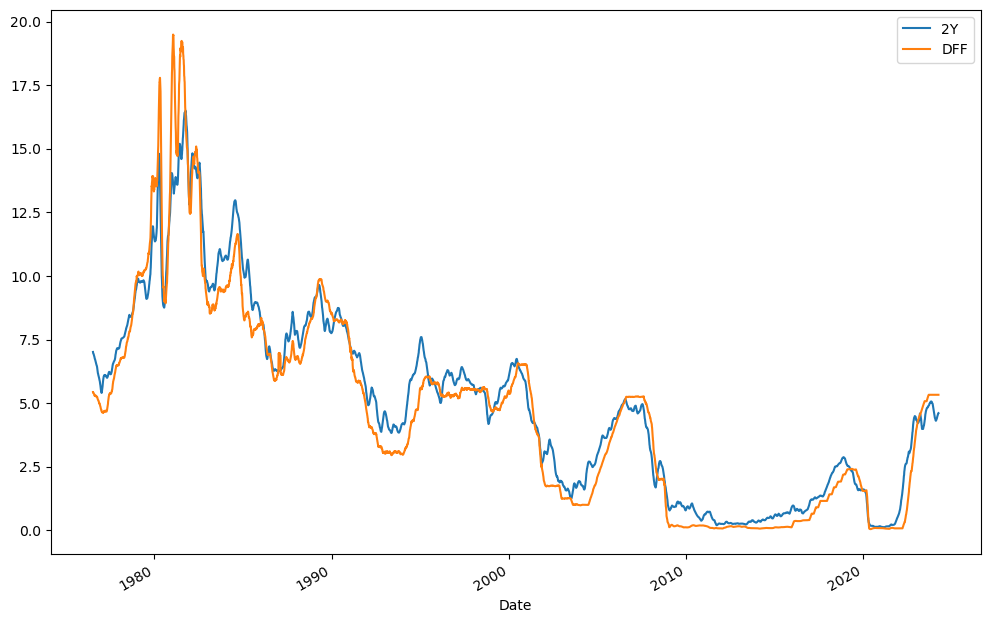

In [28]:
# check
df[['2Y', 'DFF']].dropna().fillna(method='bfill').rolling(30).mean().plot(figsize= (12,8))

# Get Signal 

In [29]:
# define momentum
# ======================================================================================================================
df_sm = make_sma(df[['Slope2Y']], spans=[50])
df_all = df.join(df_sm).dropna()
df_assets.index.name = df_all.index.name

# generate signal
# ======================================================================================================================
df_all['Signal_ls'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, -1) # long/short strategy 

df_all['Signal_ln'] = np.where(df_all['Slope2Y'] > df_all['Slope2Y_sm50'], 1, 0)  # only long strategy 

# actions for long / short strategy 
df_all[['Signal_Action']] = np.where(df_all[['Signal_ls']]==1, 'Long USD / Short Yen', 'Short USD / Long Yen')

<Axes: xlabel='Date'>

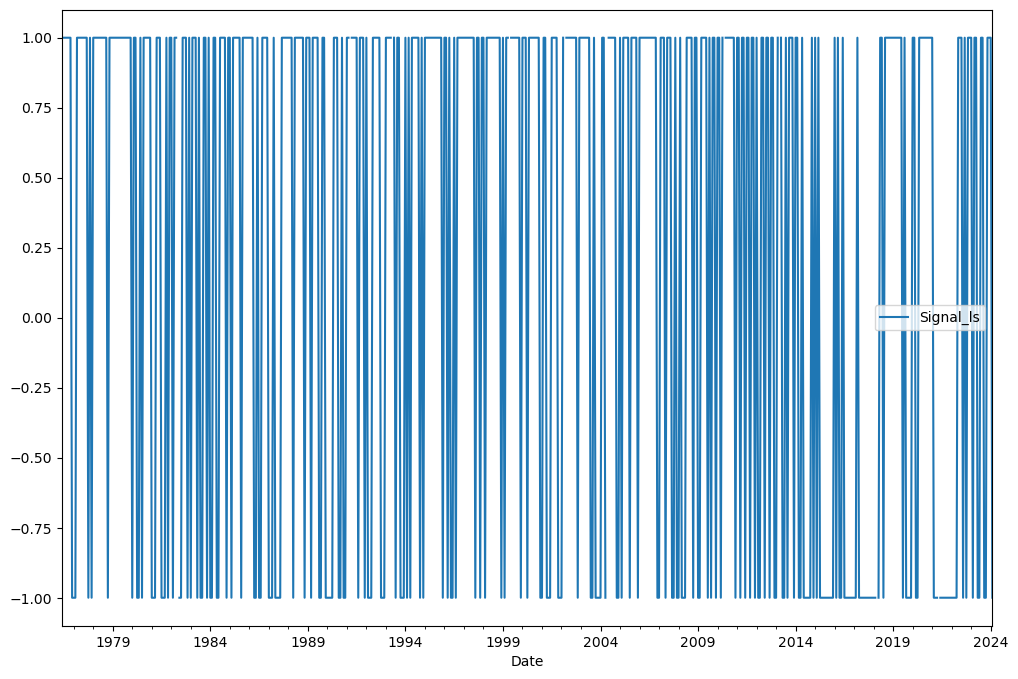

In [30]:
# check signal 
df_all[['Signal_ls']].dropna().asfreq('BM').plot(figsize=(12,8))

In [31]:
# merge all
# ======================================================================================================================
df_all = df_all.join(df_assets)

# Assess Performance 

In [32]:
# Assess both strategies # ======================================================================================================================
df_perm = pd.DataFrame(index=df_all.index)
for col in ['JPYUSD']:
    # df_perm[col] = performance(signal=df_all['Signal'], returns=np.log(df_all[col]).diff()).cumsum()
    ret_temp = returns_from_prices(df_all[col])
    df_perm['Strategy_L/S'] = performance(signal=df_all['Signal_ls'], returns=ret_temp)
    #df_perm[col + '_no_TC'] = performance(signal=df_all['Signal_ls'], returns=ret_temp, bps=0)
    df_perm['Strategy_Long_Only'] = performance(signal=df_all['Signal_ln'], returns=ret_temp)
    # df_perm[col + 'str2'] = performance(signal=df_all['Signal2'], returns=np.log(df_all[col]).diff())

In [33]:
# from wide to long to plot
# ======================================================================================================================
dfm = df_perm.cumsum().dropna().reset_index().melt(id_vars='Date', var_name='Strategy', value_name='performance')
dfm['asset'] = [x.split('str')[0] for x in dfm.Strategy]
dfm

,Date,Strategy,performance,asset
0,1996-10-31,Strategy_L/S,0.000000,Strategy_L/S
1,1996-11-01,Strategy_L/S,0.005991,Strategy_L/S
2,1996-11-04,Strategy_L/S,0.002654,Strategy_L/S
3,1996-11-05,Strategy_L/S,-0.000584,Strategy_L/S
4,1996-11-06,Strategy_L/S,0.002049,Strategy_L/S
...,...,...,...,...
13703,2024-03-20,Strategy_Long_Only,1.035532,Strategy_Long_Only
13704,2024-03-21,Strategy_Long_Only,1.035532,Strategy_Long_Only
13705,2024-03-22,Strategy_Long_Only,1.035532,Strategy_Long_Only
13706,2024-03-25,Strategy_Long_Only,1.035332,Strategy_Long_Only


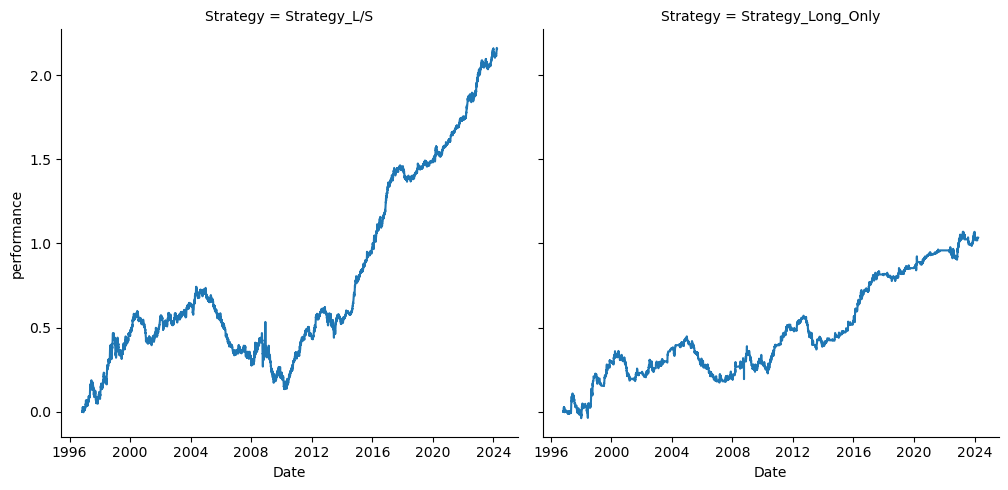

In [34]:
# plot strategies performance 
g = sns.relplot(data=dfm, x='Date', y='performance', col='Strategy', col_wrap=3, kind='line')

In [35]:
# stats
df_perm_stats = performance_overview(df_perm, short=True).sort_values(by=['cagr'], ascending=False)
df_perm_stats


,start,end,total_return,cagr,max_drawdown,yearly_sharpe,yearly_sortino,calmar
Strategy_L/S,1996-10-31 00:00:00,2024-03-26 00:00:00,6.127754,0.074309,-0.498288,0.585779,1.586056,0.149129
Strategy_Long_Only,1996-10-31 00:00:00,2024-03-26 00:00:00,1.566913,0.035003,-0.243313,0.422277,0.987321,0.143862


## L/S strategy 

<Axes: xlabel='Date'>

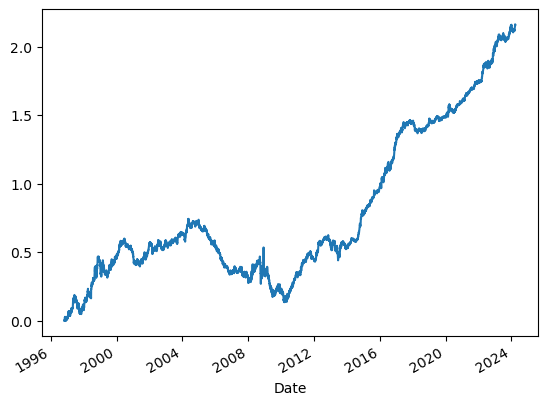

In [36]:
performance(signal=df_all['Signal_ls'], returns=df_all['JPYUSD'].pct_change()).dropna().cumsum().plot()

In [37]:
# pd.options.display.float_format = '{:.2%}'.format
qs.stats.monthly_returns(returns=df_perm[['Strategy_L/S']].dropna(), eoy=True)

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,EOY
1996,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003339,0.024248,0.027669
1997,0.035601,-0.017896,0.012629,0.030879,0.064291,0.003785,-0.031110,-0.033598,-0.021246,0.007587,0.001035,0.020394,0.069830
1998,0.037037,0.005887,0.067762,-0.003440,-0.021352,0.088369,0.028206,0.031129,0.017610,0.039006,0.061508,-0.044770,0.343840
1999,-0.084849,0.079914,-0.034216,-0.020808,-0.006653,-0.002546,0.065186,-0.015738,0.015716,0.021022,0.035163,-0.008460,0.033440
2000,0.040251,0.017333,0.070221,-0.012071,-0.001657,0.015282,-0.044030,0.002759,-0.013502,-0.006067,-0.003496,-0.035444,0.024632
2001,-0.054872,-0.010548,0.023654,-0.013195,-0.034609,0.044322,-0.022698,0.045496,-0.004004,0.011038,0.028263,0.066054,0.074156
2002,0.003988,-0.036458,-0.005074,0.005311,-0.011985,0.037985,-0.002171,0.011399,-0.027908,-0.011378,0.012505,0.044993,0.018292
2003,-0.037619,0.010376,0.019160,-0.007403,-0.004024,0.025588,0.014048,-0.035856,0.047997,0.013852,0.016644,-0.003405,0.057523
2004,-0.015572,-0.042785,0.056204,0.067130,-0.005200,-0.011790,0.014088,0.020061,-0.008267,0.006076,-0.013029,0.001095,0.064758
2005,-0.036331,-0.013142,0.002765,0.025100,-0.034594,-0.015213,-0.010606,-0.032130,-0.024766,0.009108,-0.029702,-0.002295,-0.152108


In [38]:
ret_bench = df_stock.pct_change()
df_temp = df_perm.join(ret_bench).dropna()

<Axes: >

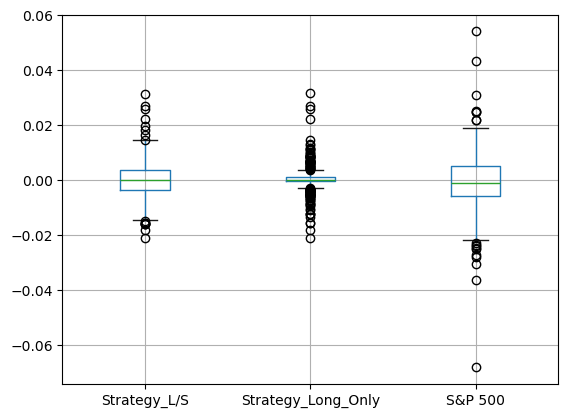

In [39]:
monthly = df_temp.resample('M').last()
monthly.boxplot()

In [40]:
df_main_stats = get_main_stats(df_temp[df_temp.index>='2010-01-01'])
df_main_stats

get_main_stats took 99.60ms


,total_ret,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
Strategy_L/S,5.521398,0.140816,0.992456,0.928474,0.557367,-0.170843
Strategy_Long_Only,1.055043,0.051910,0.069484,0.065836,0.192174,-0.185029
S&P 500,3.503238,0.111518,0.400291,0.409617,0.223214,-0.339250


In [41]:
df_temp

,Strategy_L/S,Strategy_Long_Only,S&P 500
Date,,,
1996-10-31,0.000000,0.000000,0.006235
1996-11-01,0.005991,0.005991,-0.002127
1996-11-04,-0.003337,-0.003337,0.004206
1996-11-05,-0.003239,-0.003239,0.010485
1996-11-06,0.002633,0.002633,0.014633
...,...,...,...
2024-03-20,0.012520,-0.000000,0.008904
2024-03-21,-0.001824,0.000000,0.003237
2024-03-22,0.005757,-0.000000,-0.001402


In [43]:
df_temp

,Strategy_L/S,Strategy_Long_Only,S&P 500
Date,,,
1996-10-31,0.000000,0.000000,0.006235
1996-11-01,0.005991,0.005991,-0.002127
1996-11-04,-0.003337,-0.003337,0.004206
1996-11-05,-0.003239,-0.003239,0.010485
1996-11-06,0.002633,0.002633,0.014633
...,...,...,...
2024-03-20,0.012520,-0.000000,0.008904
2024-03-21,-0.001824,0.000000,0.003237
2024-03-22,0.005757,-0.000000,-0.001402


                           Benchmark    Strategy
-------------------------  -----------  -----------
Start Period               1996-11-01   1996-11-01
End Period                 2024-03-26   2024-03-26
Risk-Free Rate             5.0%         5.0%
Time in Market             100.0%       100.0%

Cumulative Return          552.57%      596.89%
CAGR﹪                     4.84%        5.01%

Sharpe                     0.2          0.25
Prob. Sharpe Ratio         3.92%        24.91%
Smart Sharpe               0.18         0.22
Sortino                    0.28         0.36
Smart Sortino              0.25         0.31
Sortino/√2                 0.2          0.25
Smart Sortino/√2           0.17         0.22
Omega                      1.05         1.05

Max Drawdown               -59.99%      -49.87%
Longest DD Days            2594         4005
Volatility (ann.)          19.35%       11.93%
R^2                        0.0          0.0
Information Ratio          -0.0         -0.0
Calmar            

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2004-05-14,2010-05-04,2015-05-01,4005,-49.866741,-48.696698
2,2000-06-23,2001-06-04,2003-11-26,1252,-18.780746,-17.927388
3,1998-11-16,1999-06-11,2000-01-05,416,-14.922106,-13.824718
4,1997-06-12,1997-11-10,1998-03-27,289,-13.333828,-13.035688
5,2017-11-07,2018-04-18,2019-01-02,422,-9.213991,-8.934896


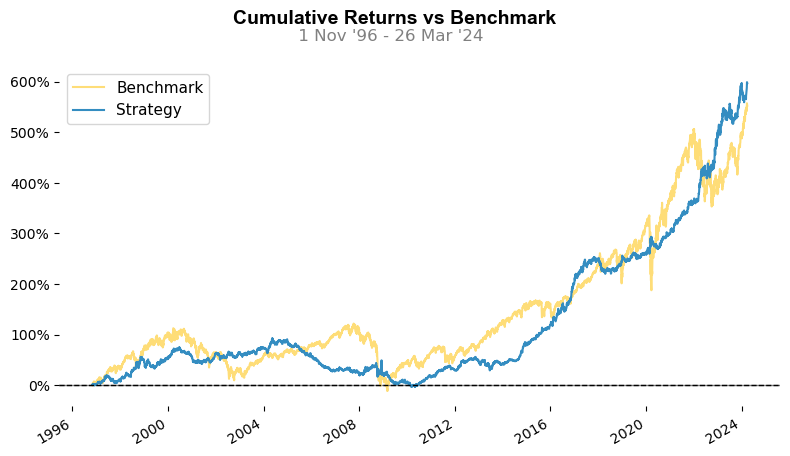

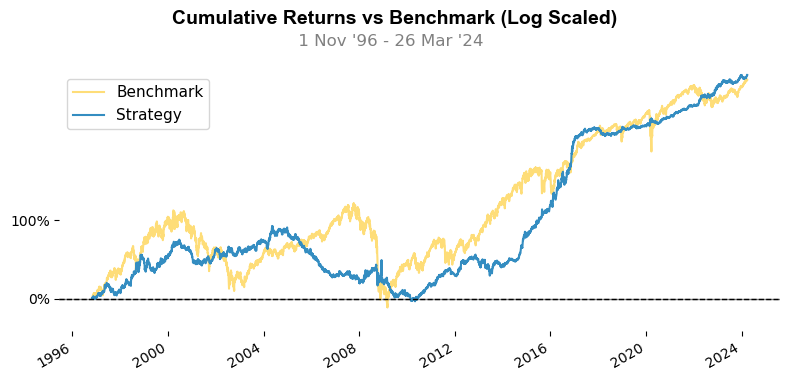

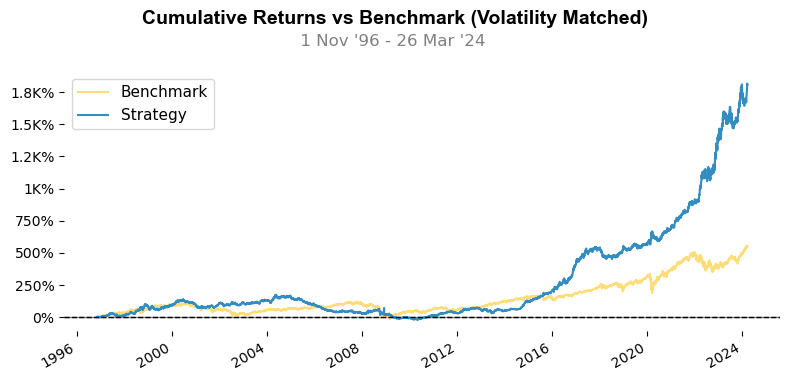

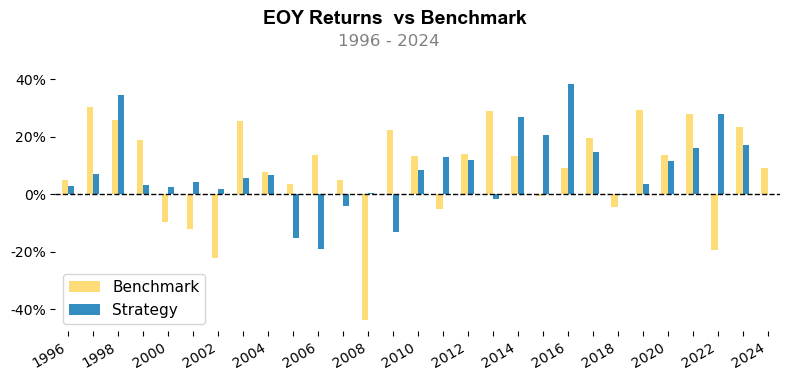

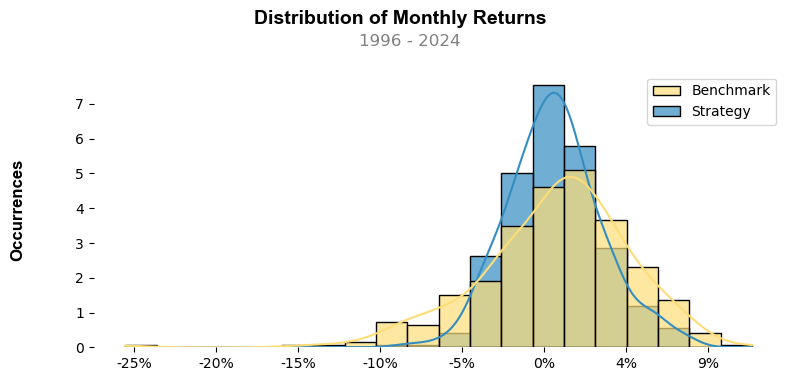

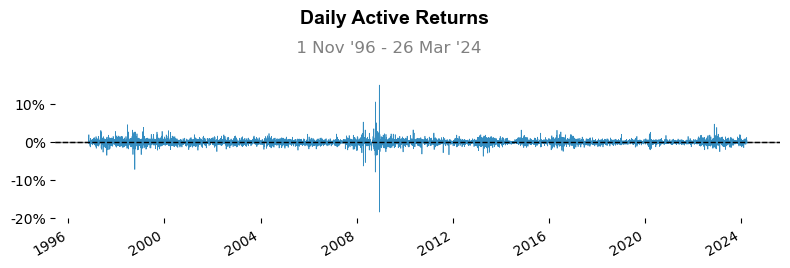

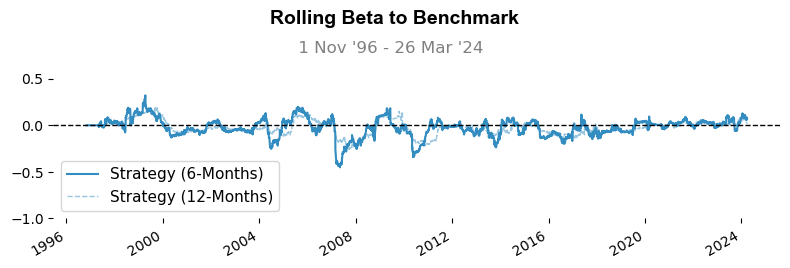

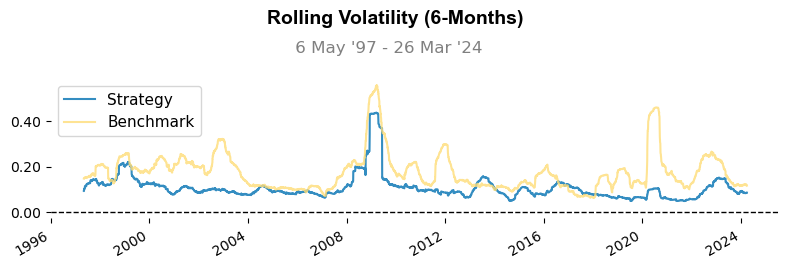

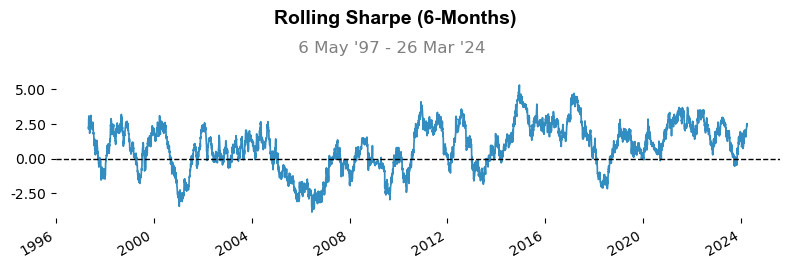

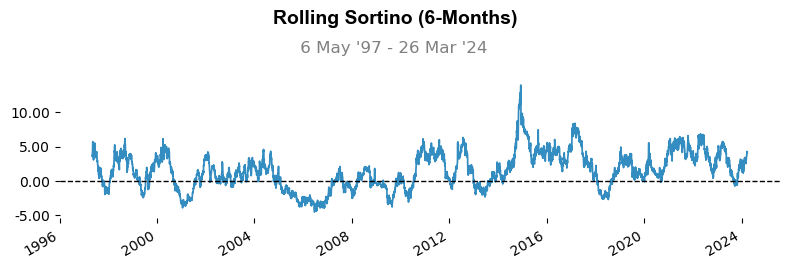

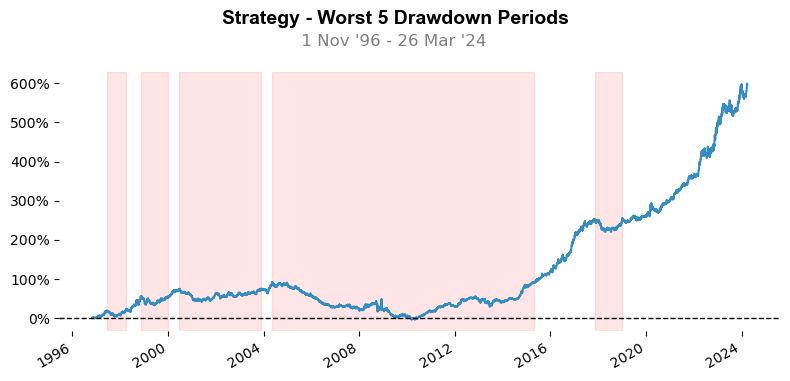

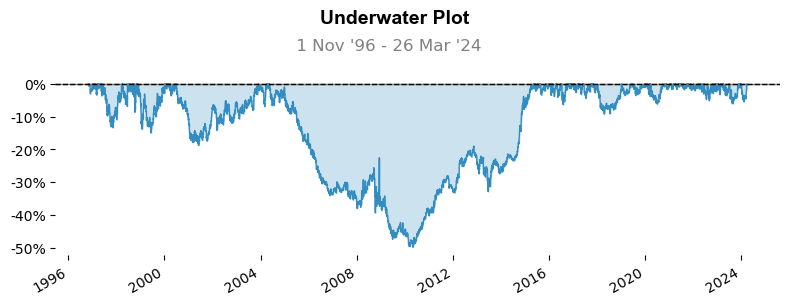

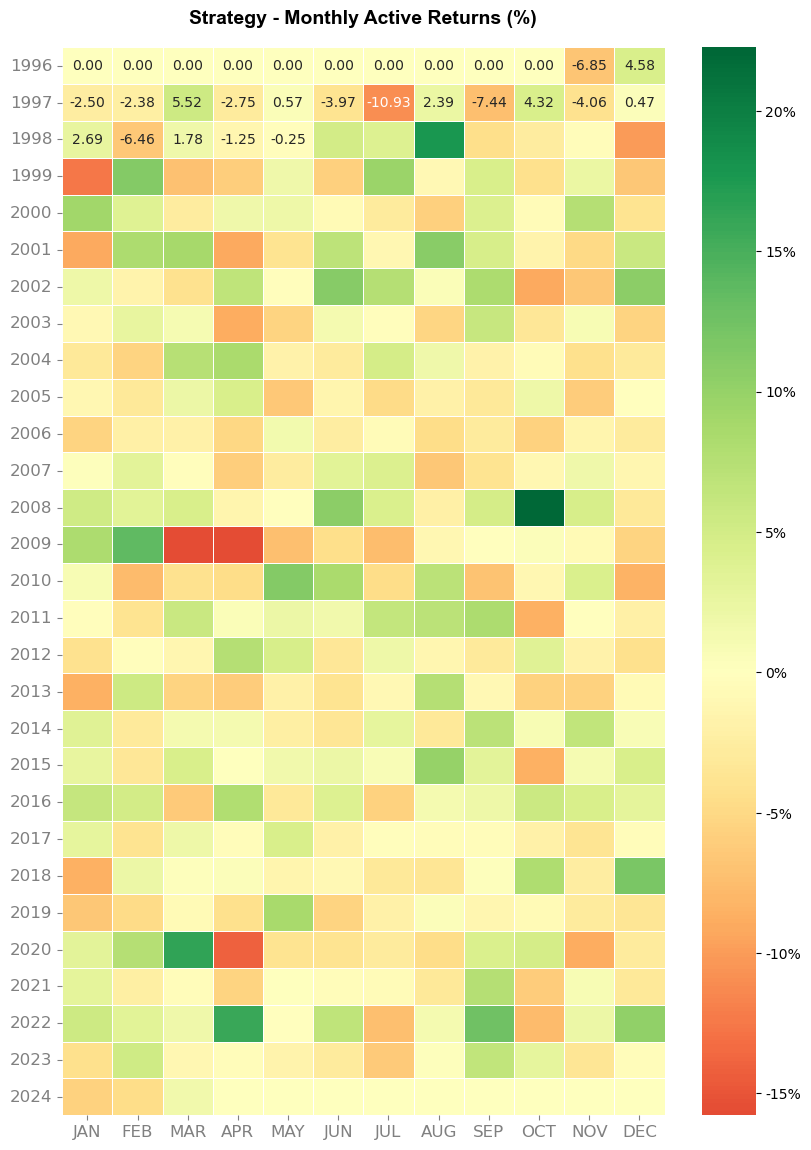

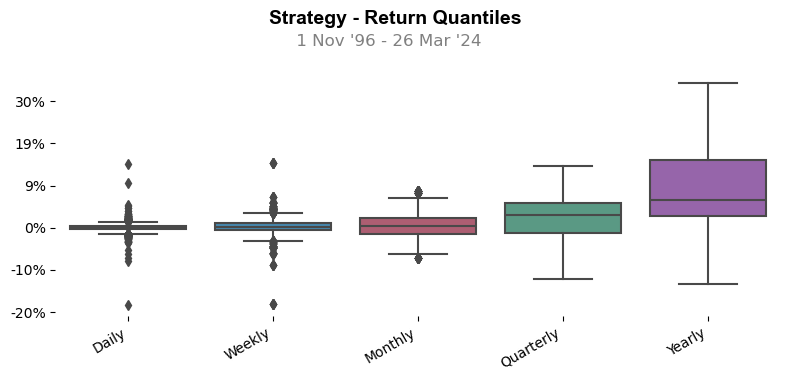

In [44]:
qs.reports.full(df_temp['Strategy_L/S'], benchmark=df_temp['S&P 500'], rf=0.05)

# Risk Analysis 

In [45]:
ret_boostp = bootstrappingTS(df_perm['Strategy_L/S'].dropna(), n_samples=10000, bootstrap_type='mbb', block_size=365*2, 
                             optimal_block = False, 
                                          seed=123)

bootstrappingTS took 3.550sec


get_main_stats took 98.464sec


<Axes: ylabel='Density'>

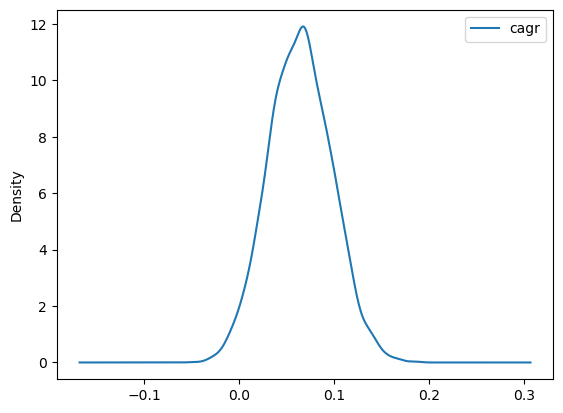

In [46]:
stats_boostp = get_main_stats(ret_boostp)

In [ ]:
stats_boostp[['cagr']].plot.density()

In [ ]:
df_hist = get_main_stats(df_temp)
df_hist

In [ ]:
boost_mean = ret_boostp.resample('Y').last().mean().mean()

In [ ]:
hist_ret = returns_from_prices(df_assets['JPYUSD']).resample('Y').last().dropna()

In [ ]:
sns.distplot(ret_boostp.resample('Y').last().mean(), hist=True)
plt.axvline(x=hist_ret.mean(), color='g', linestyle='-', label='Historical')
plt.axvline(x=boost_mean, color='r', linestyle='--', label='Expected')
plt.title('Expected Returns(%)')
plt.legend()

In [ ]:
metric = 'sharpe'
hist_sharp = df_hist.loc['JPYUSD']['sharpe']
boost_sharp = stats_boostp[['sharpe']].mean()[0]
sns.distplot(stats_boostp[metric], hist=True)
plt.axvline(x=hist_sharp, color='r', linestyle='-', label = 'Historical Sharp')
plt.axvline(x=boost_sharp, color='g', linestyle='-', label = 'Expected Sharp')
plt.title('Expected Sharp')
plt.legend()

In [ ]:
hist_ret.index = pd.to_datetime(hist_ret.index).normalize()
sns.distplot(hist_ret*100, hist=True)

In [ ]:
dist = prep_dist(ret_boostp)

In [ ]:
dist['0.95'].plot()

In [ ]:
dist_cum = ep.cum_returns(dist, starting_value=1)

In [ ]:
pd.set_option('display.float_format', str)
round(dist_cum['0.95'],2)

In [ ]:
plot_fan_chart(df_temp[['JPYUSD']],dist_cum, out_of_sample_date='2023-05-12',
                   starting_value=1,
                   chart_title='Expected Returns')

In [ ]:
returns_from_prices(df_assets).dropna().plot.density()